# Weekend 1 sanity check

Three signals through the standard interface: yoga (leading), auto repair (counter), whole foods (anchor). For each one: total count, distribution by neighborhood, distribution by establishment year, simple openings-per-year chart. Eyeball test at the end.

Run prerequisites first (from project root):
```
python -m pipelines.load_licences
python -m pipelines.classify_categories
python -m pipelines.geocode
```

In [1]:
import sys
from pathlib import Path

# Allow importing from the project root when launched from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import duckdb
import matplotlib.pyplot as plt
import polars as pl

from signals.leading.yoga_studios import get_signal as get_yoga
from signals.counter.auto_repair import get_signal as get_auto_repair
from signals.anchor.whole_foods_openings import get_signal as get_whole_foods

CHART_DIR = ROOT / 'analysis' / 'composite_index' / 'weekend_1_charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(ROOT / 'vancouver_signals.duckdb'), read_only=True)
print('connected to', ROOT / 'vancouver_signals.duckdb')

connected to /Users/kevin/code/vancouver-signals/vancouver_signals.duckdb


In [2]:
def summarize(df, label):
    print(f'--- {label} ---')
    print(f'  rows: {df.height:,}')
    print(f'  with closure_date: {df["closure_date"].is_not_null().sum():,}')
    print(f'  with neighborhood: {df["neighborhood"].is_not_null().sum():,}')
    print(f'  left-censored (est. <= 1997): {df["is_left_censored"].sum():,}')
    if df.height:
        print(f'  est. date range: {df["establishment_date"].min()} to {df["establishment_date"].max()}')

def by_neighborhood(df, top=10, exclude_left_censored=True):
    if exclude_left_censored:
        df = df.filter(~pl.col('is_left_censored'))
    return (
        df.filter(pl.col('neighborhood').is_not_null())
          .group_by('neighborhood').len()
          .sort('len', descending=True).head(top)
    )

def openings_by_year(df, exclude_left_censored=True):
    if exclude_left_censored:
        df = df.filter(~pl.col('is_left_censored'))
    return (
        df.with_columns(pl.col('establishment_date').dt.year().alias('year'))
          .group_by('year').len()
          .sort('year')
    )

def plot_openings(df, title, slug, exclude_left_censored=True):
    """Bar chart of openings by year. Left-censored rows (establishment_date <= 1997)
    are excluded by default; pass exclude_left_censored=False to include them and see
    the artifactual pre-2000 spike."""
    by_year = openings_by_year(df, exclude_left_censored=exclude_left_censored)
    years = by_year['year'].to_list()
    counts = by_year['len'].to_list()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(years, counts)
    suffix = ' (excludes left-censored)' if exclude_left_censored else ' (all rows)'
    ax.set_title(title + suffix)
    ax.set_xlabel('Establishment year')
    ax.set_ylabel('New businesses')
    fig.tight_layout()
    out = CHART_DIR / f'{slug}_openings_by_year.png'
    fig.savefig(out, dpi=120)
    print(f'  saved {out.relative_to(ROOT)}')
    plt.show()

## Yoga studios (leading)

In [3]:
yoga = get_yoga(con)
summarize(yoga, 'yoga_studios')
print()
print('top neighborhoods:')
print(by_neighborhood(yoga))

--- yoga_studios ---
  rows: 154
  with closure_date: 36
  with neighborhood: 115
  left-censored (est. <= 1997): 0
  est. date range: 2000-07-25 to 2026-04-21

top neighborhoods:
shape: (10, 2)
┌─────────────────────┬─────┐
│ neighborhood        ┆ len │
│ ---                 ┆ --- │
│ str                 ┆ u32 │
╞═════════════════════╪═════╡
│ Kitsilano           ┆ 23  │
│ Downtown            ┆ 20  │
│ Mount Pleasant      ┆ 12  │
│ Fairview            ┆ 11  │
│ Riley Park          ┆ 7   │
│ Renfrew-Collingwood ┆ 6   │
│ Grandview-Woodland  ┆ 6   │
│ West End            ┆ 5   │
│ Marpole             ┆ 4   │
│ Out of Town         ┆ 4   │
└─────────────────────┴─────┘


  saved analysis/composite_index/weekend_1_charts/yoga_openings_by_year.png


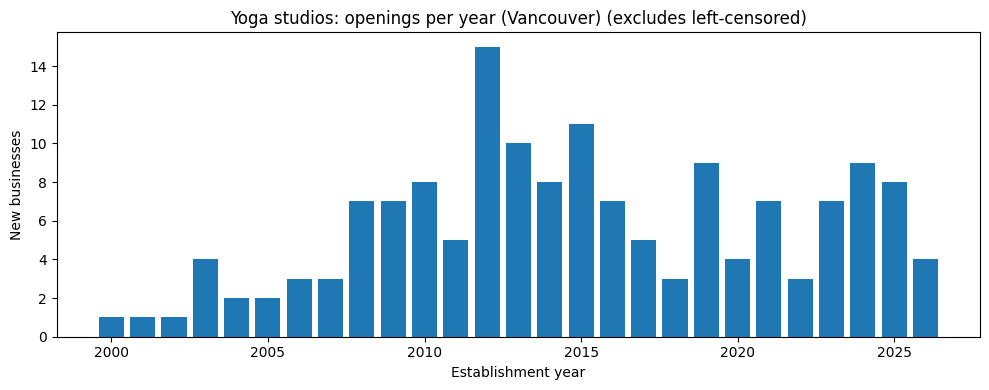

In [4]:
plot_openings(yoga, 'Yoga studios: openings per year (Vancouver)', 'yoga')

## Auto repair (counter)

In [5]:
auto = get_auto_repair(con)
summarize(auto, 'auto_repair')
print()
print('top neighborhoods:')
print(by_neighborhood(auto))

--- auto_repair ---
  rows: 1,739
  with closure_date: 514
  with neighborhood: 1,138
  left-censored (est. <= 1997): 491
  est. date range: 1997-01-03 to 2026-03-19

top neighborhoods:
shape: (10, 2)
┌──────────────────────────┬─────┐
│ neighborhood             ┆ len │
│ ---                      ┆ --- │
│ str                      ┆ u32 │
╞══════════════════════════╪═════╡
│ Grandview-Woodland       ┆ 151 │
│ Marpole                  ┆ 138 │
│ Strathcona               ┆ 113 │
│ Kensington-Cedar Cottage ┆ 86  │
│ Mount Pleasant           ┆ 85  │
│ Fairview                 ┆ 65  │
│ Sunset                   ┆ 56  │
│ Downtown                 ┆ 45  │
│ Kitsilano                ┆ 32  │
│ Hastings-Sunrise         ┆ 25  │
└──────────────────────────┴─────┘


  saved analysis/composite_index/weekend_1_charts/auto_repair_openings_by_year.png


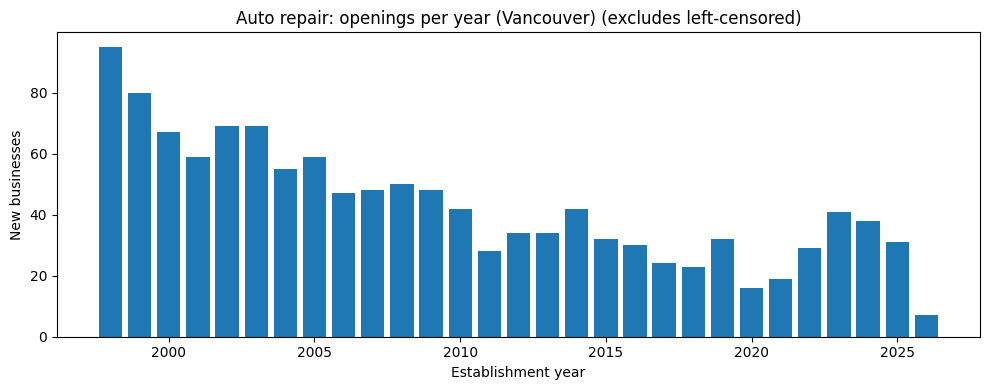

In [6]:
plot_openings(auto, 'Auto repair: openings per year (Vancouver)', 'auto_repair')

## Whole Foods openings (anchor)

Anchor signals are rare by construction. Showing every row. With the tightened name match (`whole foods market`, not just `whole foods`) we should see 3-4 distinct Vancouver locations: Cambie/8th, Robson, and Kitsilano/4th. Park Royal is West Vancouver and won't appear.

In [7]:
wf = get_whole_foods(con)
summarize(wf, 'whole_foods_openings')
print()
with pl.Config(fmt_str_lengths=80, tbl_cols=-1):
    print(wf.select(['name', 'address', 'neighborhood', 'establishment_date', 'closure_date', 'is_left_censored']))

--- whole_foods_openings ---
  rows: 3
  with closure_date: 0
  with neighborhood: 3
  left-censored (est. <= 1997): 0
  est. date range: 2009-07-08 to 2010-09-01

shape: (3, 6)
┌─────────────────┬────────────────┬──────────────┬────────────────┬──────────────┬────────────────┐
│ name            ┆ address        ┆ neighborhood ┆ establishment_ ┆ closure_date ┆ is_left_censor │
│ ---             ┆ ---            ┆ ---          ┆ date           ┆ ---          ┆ ed             │
│ str             ┆ str            ┆ str          ┆ ---            ┆ date         ┆ ---            │
│                 ┆                ┆              ┆ date           ┆              ┆ bool           │
╞═════════════════╪════════════════╪══════════════╪════════════════╪══════════════╪════════════════╡
│ Whole Foods     ┆ 1675 ROBSON ST ┆ West End     ┆ 2010-09-01     ┆ null         ┆ false          │
│ Market - Wo Inc ┆                ┆              ┆                ┆              ┆                │
│ Whole Foods 

  saved analysis/composite_index/weekend_1_charts/whole_foods_openings_by_year.png


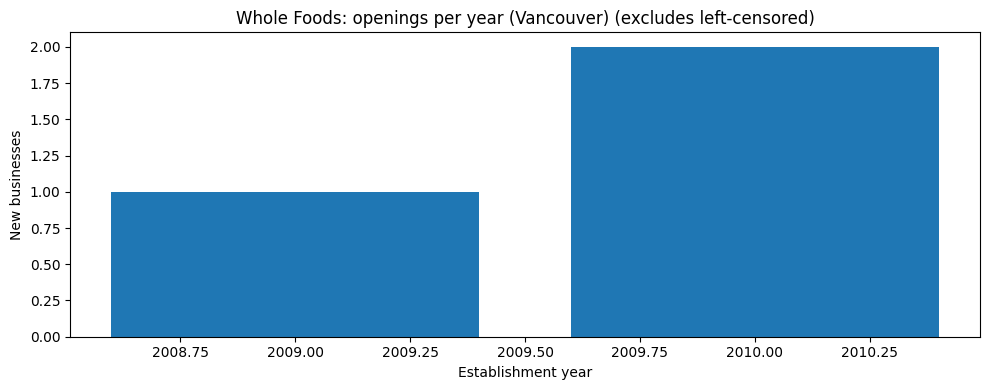

In [8]:
plot_openings(wf, 'Whole Foods: openings per year (Vancouver)', 'whole_foods')

## Eyeball test

What we're checking, with no statistical claims yet:

1. **Yoga**: low pre-2010, growing through the 2010s, plateau or decline post-2020? If yes, the signal behaves the way a leading-indicator hypothesis would predict.
2. **Auto repair**: opposite shape? With the cleanup pass (broader auto canonical, May 2024 bridging, left-censored filter), the 1997 cliff and the 2024 spike should both be gone. The remaining curve should show a clean decline from late 90s through mid-2010s.
3. **Whole Foods**: 3 Vancouver locations now after the tightened name match. Cambie 2009, Robson 2010, Kitsilano 2010.

Caveats that still affect every chart:

- `establishment_date` is the earliest issue_date we see for that business_id. Charts default to excluding left-censored rows (`establishment_date <= 1997`); pass `exclude_left_censored=False` to see them.
- `business_id` is `hash(normalized_name + " " + normalized_address)` with corp-suffix and street-type normalization. Better than the Weekend 1 version but still imperfect: same name in two units of the same building still over-merge; minor name typos still under-merge.
- ~50% of historical licence rows have no geometry, with the missingness biased toward home-based and mobile businesses. See `data/README.md` "Known limitations" for the full breakdown. Neighborhood-level counts undercount any signal class with a heavy mobile-services component.
- Closure-date heuristic is based on the most recent licence row's status. The spot-check lists in `analysis/composite_index/spot_checks/` are how we validate it manually.